In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd


In [26]:
url = "https://api.open-meteo.com/v1/forecast"    
params = {
    "latitude": 32.117,  # Latitude for Tokyo
    "longitude": -110.941,  # Longitude for Tokyo
    "hourly": "temperature_2m,relative_humidity_2m",
    "timezone":"GMT",
    "models": "ncep_gfs_seamless"
}

In [27]:
response = requests.get(url, params=params)
data = response.json()

In [28]:
current_temp = data['hourly']['temperature_2m'][:]  # Get the current temperature   
print(f"Current temperature in Tokyo: {current_temp}°C")

Current temperature in Tokyo: [32.5, 33.0, 29.4, 28.6, 27.9, 27.5, 25.5, 24.6, 24.1, 24.1, 23.8, 22.9, 23.6, 23.6, 25.5, 27.4, 30.4, 32.8, 35.3, 36.9, 34.0, 36.5, 31.3, 33.2, 30.1, 30.8, 29.1, 27.6, 27.4, 26.7, 26.2, 25.8, 25.2, 24.8, 24.3, 23.6, 23.2, 23.4, 26.1, 28.9, 31.3, 32.6, 33.5, 33.9, 35.3, 36.2, 36.2, 34.4, 34.8, 35.6, 35.3, 34.6, 34.3, 33.0, 31.4, 31.0, 27.8, 27.0, 27.3, 27.9, 28.3, 28.0, 28.5, 29.6, 30.9, 32.0, 32.9, 33.9, 35.2, 36.2, 37.3, 37.7, 36.8, 35.7, 34.3, 32.7, 29.1, 30.1, 29.0, 29.1, 29.5, 29.7, 29.7, 29.3, 28.9, 28.7, 29.0, 29.6, 30.5, 31.5, 32.7, 34.2, 35.9, 37.1, 37.0, 35.1, 30.9, 28.5, 28.1, 28.2, 27.6, 27.0, 27.0, 27.6, 27.6, 27.7, 27.8, 27.7, 26.7, 26.0, 26.5, 27.4, 28.4, 29.4, 30.6, 31.9, 33.3, 34.4, 35.4, 36.0, 35.5, 33.1, 29.5, 26.8, 25.8, 25.5, 25.4, 25.3, 25.4, 25.4, 25.4, 25.3, 25.3, 25.5, 25.8, 26.2, 27.0, 27.9, 28.4, 28.3, 28.0, 27.8, 28.3, 29.1, 29.6, 29.7, 29.4, 29.2, 29.1, 28.9, 28.7, 28.3, 27.9, 27.5, 27.3, 27.2, 27.2, 27.4, 27.8, 28.4, 29.4, 30.

In [29]:
print(np.shape(current_temp))

(168,)


In [30]:
print(data)

{'latitude': 32.117096, 'longitude': -110.94665, 'generationtime_ms': 0.4820823669433594, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 790.0, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%'}, 'hourly': {'time': ['2026-07-13T00:00', '2026-07-13T01:00', '2026-07-13T02:00', '2026-07-13T03:00', '2026-07-13T04:00', '2026-07-13T05:00', '2026-07-13T06:00', '2026-07-13T07:00', '2026-07-13T08:00', '2026-07-13T09:00', '2026-07-13T10:00', '2026-07-13T11:00', '2026-07-13T12:00', '2026-07-13T13:00', '2026-07-13T14:00', '2026-07-13T15:00', '2026-07-13T16:00', '2026-07-13T17:00', '2026-07-13T18:00', '2026-07-13T19:00', '2026-07-13T20:00', '2026-07-13T21:00', '2026-07-13T22:00', '2026-07-13T23:00', '2026-07-14T00:00', '2026-07-14T01:00', '2026-07-14T02:00', '2026-07-14T03:00', '2026-07-14T04:00', '2026-07-14T05:00', '2026-07-14T06:00', '2026-07-14T07:00', '2026-07-14T08:00', '2026-07-14T09:00', '2026-07-14T10:00', '202

In [31]:
valid_times = data['hourly']['time']

In [32]:
print(valid_times)

['2026-07-13T00:00', '2026-07-13T01:00', '2026-07-13T02:00', '2026-07-13T03:00', '2026-07-13T04:00', '2026-07-13T05:00', '2026-07-13T06:00', '2026-07-13T07:00', '2026-07-13T08:00', '2026-07-13T09:00', '2026-07-13T10:00', '2026-07-13T11:00', '2026-07-13T12:00', '2026-07-13T13:00', '2026-07-13T14:00', '2026-07-13T15:00', '2026-07-13T16:00', '2026-07-13T17:00', '2026-07-13T18:00', '2026-07-13T19:00', '2026-07-13T20:00', '2026-07-13T21:00', '2026-07-13T22:00', '2026-07-13T23:00', '2026-07-14T00:00', '2026-07-14T01:00', '2026-07-14T02:00', '2026-07-14T03:00', '2026-07-14T04:00', '2026-07-14T05:00', '2026-07-14T06:00', '2026-07-14T07:00', '2026-07-14T08:00', '2026-07-14T09:00', '2026-07-14T10:00', '2026-07-14T11:00', '2026-07-14T12:00', '2026-07-14T13:00', '2026-07-14T14:00', '2026-07-14T15:00', '2026-07-14T16:00', '2026-07-14T17:00', '2026-07-14T18:00', '2026-07-14T19:00', '2026-07-14T20:00', '2026-07-14T21:00', '2026-07-14T22:00', '2026-07-14T23:00', '2026-07-15T00:00', '2026-07-15T01:00',

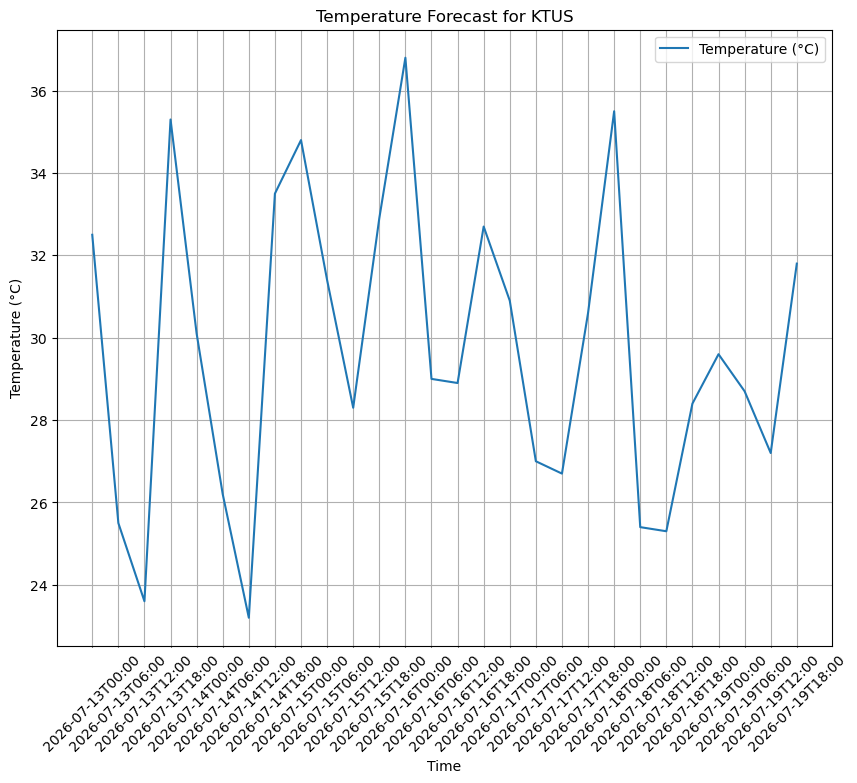

In [34]:
fig,axs = plt.subplots(1,1,figsize=(10,8))
images = []


axs.plot(valid_times[::6], current_temp[::6], label='Temperature (°C)', color='tab:blue')
axs.set_xlabel('Time')
axs.set_ylabel('Temperature (°C)')
axs.legend()
axs.grid()
axs.tick_params(axis='x', rotation=45,size=1)
axs.set_title('Temperature Forecast for KTUS')
plt.show()
